In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_ollama

In [2]:
import os, getpass

def _set_env(var: str):
    # Check if the variable is set in the OS environment
    env_value = os.environ.get(var)
    if not env_value:
        # If not set, prompt the user for input
        env_value = getpass.getpass(f"{var}: ")
    
    # Set the environment variable for the current process
    os.environ[var] = env_value

_set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

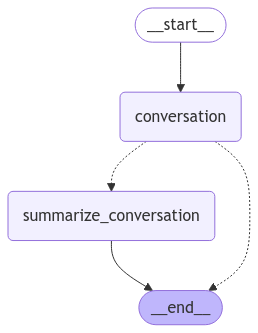

In [3]:
from langchain_ollama import ChatOllama

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

# LLM
model = ChatOllama(model="llama3.1", temperature=0) 

# State 
class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State, config: RunnableConfig):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State):
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content="Hi Lance! It's nice to meet you. Is there something on your mind that you'd like to chat about, or are you just looking for some company?", additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2024-12-20T11:14:28.626451Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1716442125, 'load_duration': 14501209, 'prompt_eval_count': 15, 'prompt_eval_duration': 357000000, 'eval_count': 34, 'eval_duration': 1344000000, 'message': Message(role='assistant', content='', images=None, tool_calls=None)}, id='run-67f352d3-665b-4db6-b1e6-ddd6479b0789-0', usage_metadata={'input_tokens': 15, 'output_tokens': 34, 'total_tokens': 49})}}


In [5]:
# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Lance")]}, config, stream_mode="updates"):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

You already said hi and introduced yourself earlier. What would you like to talk about now?


In [6]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Lance
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hi Lance! It's nice to meet you. Is there something on your mind that you'd like to chat about, or are you just looking for some company?
---------------------------------------------------------------------------


In [7]:
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: __start__. Type: on_chain_start. Name: __start__
Node: __start__. Type: on_chain_start. Name: _write
Node: __start__. Type: on_chain_end. Name: _write
Node: __start__. Type: on_chain_start. Name: _write
Node: __start__. Type: on_chain_end. Name: _write
Node: __start__. Type: on_chain_stream. Name: __start__
Node: __start__. Type: on_chain_end. Name: __start__
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: 

In [8]:
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='The', additional_kwargs={}, response_metadata={}, id='run-19b75d12-ba4d-4348-b93c-cf5b5fb15656')}
{'chunk': AIMessageChunk(content=' San', additional_kwargs={}, response_metadata={}, id='run-19b75d12-ba4d-4348-b93c-cf5b5fb15656')}
{'chunk': AIMessageChunk(content=' Francisco', additional_kwargs={}, response_metadata={}, id='run-19b75d12-ba4d-4348-b93c-cf5b5fb15656')}
{'chunk': AIMessageChunk(content=' ', additional_kwargs={}, response_metadata={}, id='run-19b75d12-ba4d-4348-b93c-cf5b5fb15656')}
{'chunk': AIMessageChunk(content='49', additional_kwargs={}, response_metadata={}, id='run-19b75d12-ba4d-4348-b93c-cf5b5fb15656')}
{'chunk': AIMessageChunk(content='ers', additional_kwargs={}, response_metadata={}, id='run-19b75d12-ba4d-4348-b93c-cf5b5fb15656')}
{'chunk': AIMessageChunk(content=' are', additional_kwargs={}, response_metadata={}, id='run-19b75d12-ba4d-4348-b93c-cf5b5fb15656')}
{'chunk': AIMessageChunk(content=' a', additional_kwargs={}, response_

In [9]:
config = {"configurable": {"thread_id": "5"}}
input_message = HumanMessage(content="Tell me about the 49ers NFL team")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|")

The| San| Francisco| |49|ers| are| a| professional| American| football| team| based| in| the| San| Francisco| Bay| Area|.| They| compete| in| the| National| Football| League| (|NFL|)| as| a| member| of| the| NFC| West| division|.

***|History|

 |49|ers| were| founded| on| November| |4|,| |194|6|,| by| Tony| Mor|ab|ito| and| were| originally| based| in| Ke|zar| Stadium| in| San| Francisco|.| The| team| was| named| after| the| California| Gold| Rush| of| |184|9|,| which| brought| thousands| of| prospect|ors| to| the| state| in| search| of| gold|.| The| team|'s| original| colors| were| red| and| white|.

Not|able| Moments|**

 **|Super| Bowl| XVI| (|198|2|)**|:| The| |49|ers| defeated| the| Cincinnati| Bengals| |26|-|21| in| their| first| Super| Bowl| appearance|.
*| **|Super| Bowl| X|IX| (|198|5|)**|:| The| |49|ers| defeated| the| Miami| Dolphins| |38|-|16|,| cement|ing| their| status| as| one| of| the| greatest| teams| of| all| time|.
Super| Bowl| XX|III| (|198|9|)**|:| The| |49|ers| d